### SIAC as Fourier Postprocessing of the Reconstructed Image

This notebook verifies the use of the SIAC kernel as a Fourier-domain postprocessor applied directly to the reconstructed image. The aim is to study whether SIAC can improve the FBP result through dimension-wise Fourier multiplication after reconstruction.

The notebook is used to test parameter configurations, inspect reconstruction behavior, and identify stable parameter ranges to be carried forward to the Monte Carlo study.

**Note:** During the verification of the $c_\gamma$ coefficients, stability and conditioning issues were observed for higher polynomial reproduction orders. In these regimes, numerical behavior may deviate from theoretical expectations, and results become increasingly sensitive and heuristic in nature.

Therefore, this study focuses on parameter ranges that exhibit stable numerical behavior, avoiding excessively high reproduction orders where conditioning becomes problematic.

In [1]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.siac_fourier import apply_siac_fft_nd

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise, 
    multi_disk_phantom_2d
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom, 
    plot_param_heatmap_single_run
)


/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


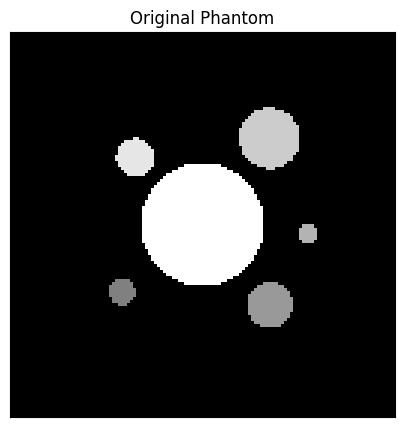

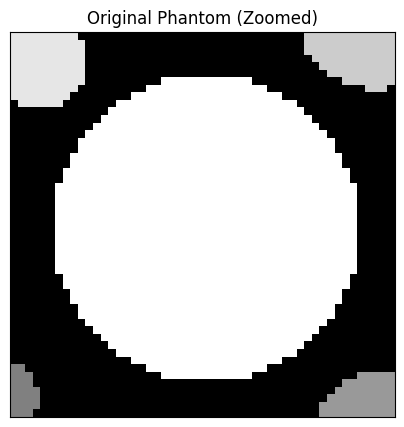

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Original Phantom (Zoomed)'}>)

In [3]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 128, 128

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
#phantom = shepp_logan_2d(space)
phantom = multi_disk_phantom_2d(space)

phantom_np = phantom.asarray()

phantom_name = "multi_disc"
# phantom_name = "shepp_logan"

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)

plot_img(img=phantom, title="Original Phantom")
plot_img_zoom(img=phantom, title="Original Phantom (Zoomed)")

In [4]:
### Compute the FBP with the ramp filter only and Hann window

# Create a Noisy phantom using the FBP
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)
fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")

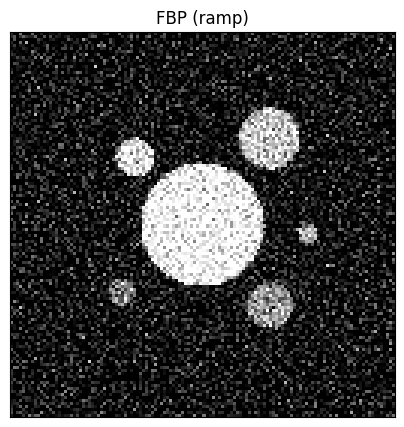

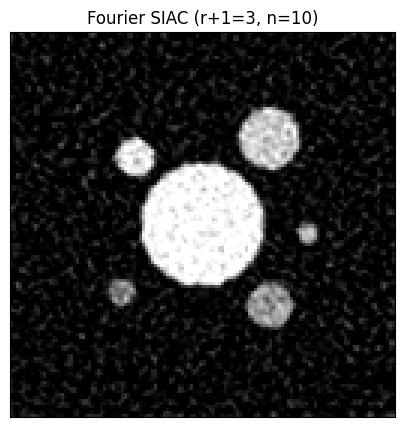

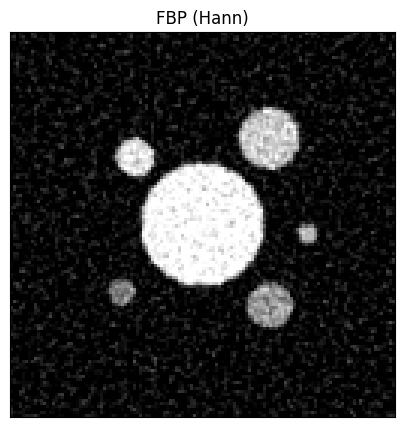

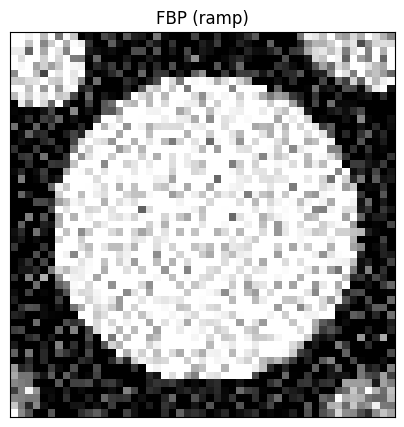

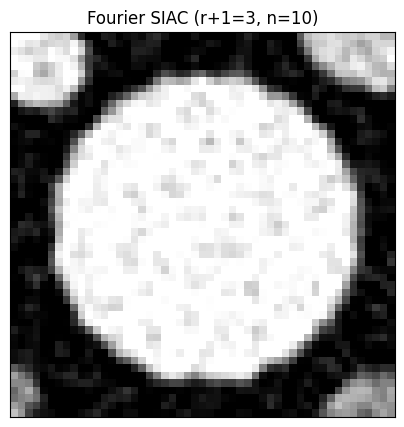

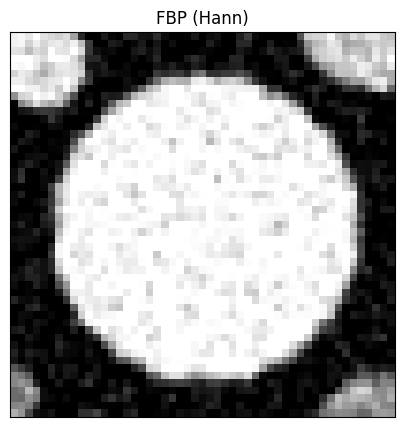

('figures/multi_disc_siac_fourier_post_r3n10.pdf',
 'figures/multi_disc_siac_fourier_post_r3n10_zoom.pdf')

In [5]:
dx, dy = space.cell_sides           # physical grid spacing (x, y)
_, d_det = data_space.cell_sides    # (angular res (rad), detector spacing)

moments = 2
BSorder = 10

# Apply SIAC after FBP with ramp filter
fbp_siac = apply_siac_fft_nd(arr=fbp_ramp, 
                             h_per_axis=(dy, dx), 
                             axes=(0, 1), 
                             moments=moments, 
                             BSorder=BSorder, 
                             pad_mode="reflect")

plot_img(img=fbp_ramp, title=f"FBP (ramp)")
plot_img(img=fbp_siac, title=f"Fourier SIAC (r+1={moments+1}, n={BSorder})")
plot_img(img=fbp_hann, title="FBP (Hann)")

plot_img_zoom(img=fbp_ramp, title=f"FBP (ramp)")
plot_img_zoom(img=fbp_siac, title=f"Fourier SIAC (r+1={moments+1}, n={BSorder})")
plot_img_zoom(img=fbp_hann, title="FBP (Hann)")

save_image_w_zoom(img=fbp_siac, save_path=f"figures/{phantom_name}_siac_fourier_post_r{moments+1}n{BSorder}.pdf")


### Testing more parameters

**Note** Recall from verification/00_siac_kernel_checks.ipynb the unstability (high condition number) from going above preserving 10 moments.

In [6]:
momentss = [2, 4, 6, 8, 10]
BSorders = [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16]

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "ramp"},
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "hann"},
    },
}

for r in momentss:
    for n in BSorders:

        # Apply SIAC after FBP with ramp filter
        fbp_siac = apply_siac_fft_nd(arr=fbp_ramp, 
                                    h_per_axis=(dy, dx), 
                                    axes=(0, 1), 
                                    moments=r, 
                                    BSorder=n, 
                                    pad_mode="reflect")
        
        name = f"Fourier SIAC r{r+1} n{n}"

        cases[name] = {
            "image": fbp_siac,
            "reference": fbp_ramp.asarray(),
            "extra": {
                "method": "Fourier-SIAC",
                "filter": "ramp",
                "moments": r+1,
                "BSorder": n,
            },
        }
        
df = build_metrics_table(cases, 
                         truth=phantom_np, 
                         dx=dx, 
                         dy=dy, compute_reference_metrics=False, 
                         mask_keep_largest=False     # False if not shepp_logan
                         )

# Since we ran a lot of experiments, we pick out the best 3 w.r.t.
# The relative L2 error, masked relative L2 error, gradient weighted SSIM, and SSIM
df_siac = df[df["method"] == "Fourier-SIAC"].copy()

best_3_l2_row = df_siac.nsmallest(3, "rel_l2_err")
best_3_masked_l2_row = df_siac.nsmallest(3, "masked_rel_l2_err")
best_3_gw_ssim = df_siac.nlargest(3, "gw_ssim")
best_3_ssim = df_siac.nlargest(3, "ssim")

df_summary = pd.concat([
    df.loc[df["name"] == "FBP-ramp"].iloc[[0]].assign(selected_as="baseline"),
    df.loc[df["name"] == "FBP-Hann"].iloc[[0]].assign(selected_as="baseline"),
    best_3_l2_row.assign(selected_as="best SIAC rel_l2"),
    best_3_masked_l2_row.assign(selected_as="best SIAC masked_rel_l2"),
    best_3_gw_ssim.assign(selected_as="best SIAC gw_ssim"),
    best_3_ssim.assign(selected_as="best SIAC ssim"),
], ignore_index=True)

cols = ["selected_as"] + [c for c in df_summary.columns if c != "selected_as"]
df_summary = df_summary[cols]

# Drop duplicates
df_summary = df_summary.drop_duplicates(subset=["name"])

df_summary

,selected_as,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error,method,filter,moments,BSorder
0,baseline,FBP-ramp,0.709868,0.119995,0.815801,0.285523,2.480831,FBP,ramp,NaN,NaN
1,baseline,FBP-Hann,0.299838,0.191871,0.916089,0.163428,1.070309,FBP,hann,NaN,NaN
2,best SIAC rel_l2,Fourier SIAC r3 n16,0.257774,0.221941,0.902323,0.172159,0.870799,Fourier-SIAC,ramp,3.0,16.0
3,best SIAC rel_l2,Fourier SIAC r3 n14,0.269072,0.210069,0.904674,0.170896,0.921173,Fourier-SIAC,ramp,3.0,14.0
4,best SIAC rel_l2,Fourier SIAC r3 n12,0.284127,0.198175,0.906495,0.170276,0.988583,Fourier-SIAC,ramp,3.0,12.0
6,best SIAC masked_rel_l2,Fourier SIAC r3 n10,0.304617,0.186311,0.907424,0.170778,1.079504,Fourier-SIAC,ramp,3.0,10.0
9,best SIAC gw_ssim,Fourier SIAC r5 n16,0.306444,0.186025,0.906736,0.172138,1.087742,Fourier-SIAC,ramp,5.0,16.0
10,best SIAC gw_ssim,Fourier SIAC r3 n8,0.333366,0.174472,0.906733,0.173361,1.203713,Fourier-SIAC,ramp,3.0,8.0


### Heatmaps

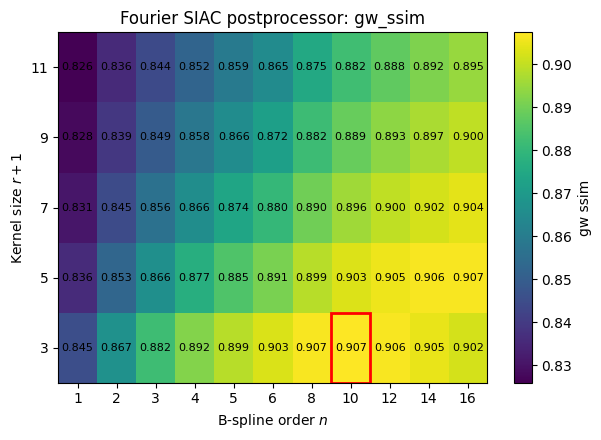

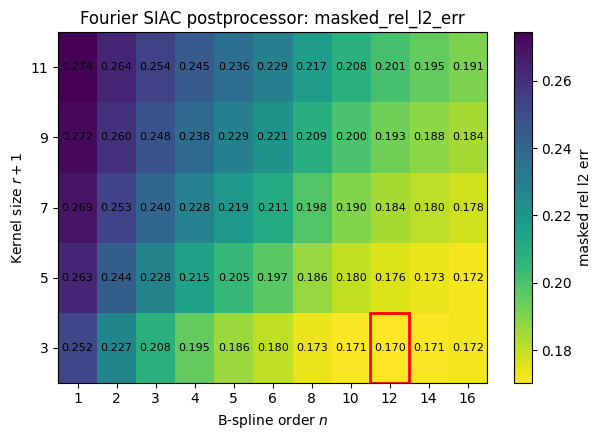

In [7]:
metrics = ["gw_ssim", "masked_rel_l2_err"]


for metric in metrics:
    cmap = "viridis_r" if metric != "gw_ssim" else "viridis"
    plot_param_heatmap_single_run(
        df,
        method="Fourier-SIAC",
        metric=metric,
        cmap=cmap,  # reverse for masked L2 error
        save_name=f"fourier_siac_post_param_heatmap_{metric}",
        minimize=(metric != "gw_ssim")  # maximize GWSSIM
    )
    plot_param_heatmap_single_run(
        df,
        method="Fourier-SIAC",
        metric=metric,
        cmap=cmap,  # reverse for masked L2 error
        title=f"Fourier SIAC postprocessor: {metric}",
        minimize=(metric != "gw_ssim")  # maximize GWSSIM
    )


From this, and the corresponding plots, the conclusion is less clear than in the DG-SIAC case.

Here, the best results are more scattered across the SIAC parameter range. The optimal parameter choices according to each metric are:

* $L^2$-error:                $r = 3, n = 16$
* Masked $L^2$-error:         $r = 3, n = 12$
* GW-SSIM:                    $r = 3, n = 10$
* SSIM:                       $r = 3, n = 16$

However, since both the $L^2$-error and SSIM measure similarity over the full image domain, they also include the empty background outside the phantom. As a result, higher smoothness parameters may be favored due to stronger attenuation of high-frequency components in these background regions, rather than improved reconstruction quality within the phantom itself.

This effect is clearly reflected in the masked metrics. Both the gradient-weighted SSIM and the masked relative $L^2$-error favor more moderate levels of smoothing, indicating that excessive smoothing primarily improves the background rather than the structurally relevant regions of the image.

Therefore, we may conclude that moderate values of the smoothness parameter ($n = 3\text{--}7$) and low-to-moderate polynomial reproduction ($r = 3\text{--}5$) provide the best balance between noise suppression and feature preservation.

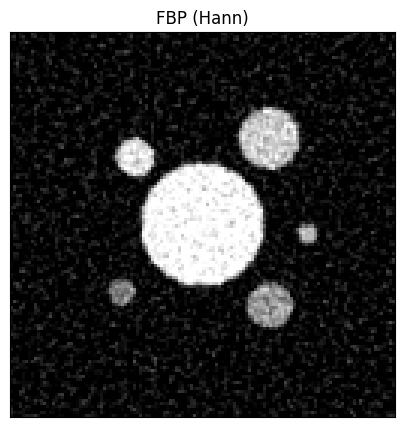

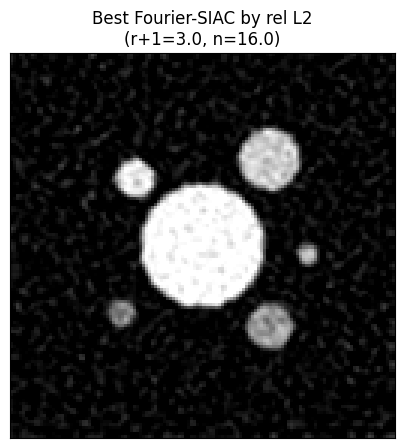

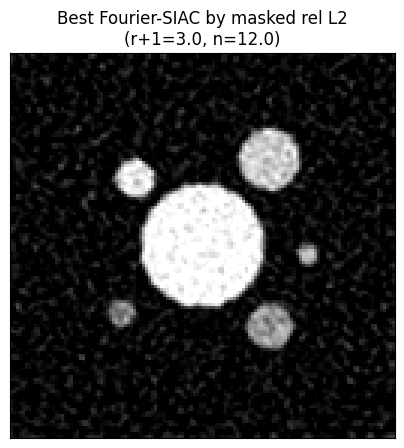

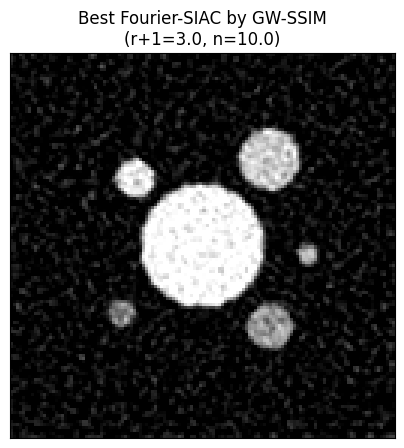

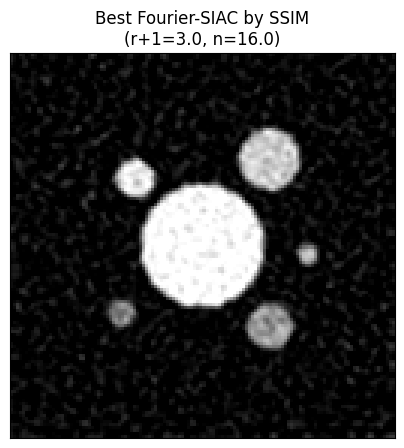

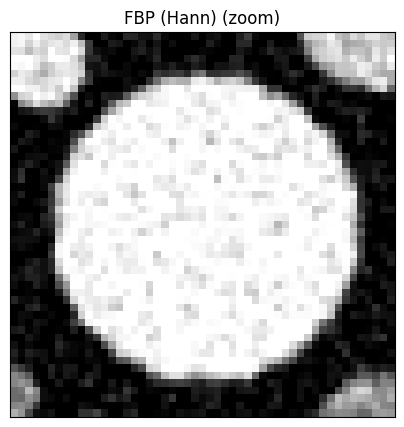

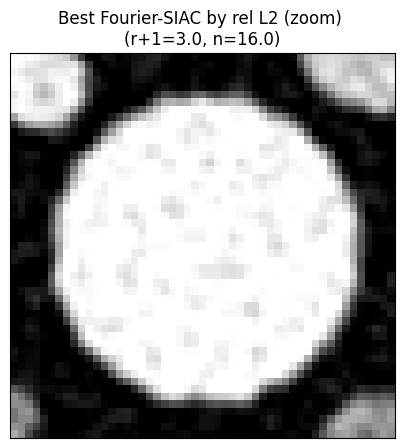

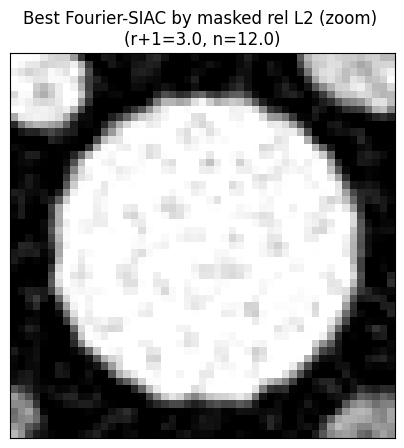

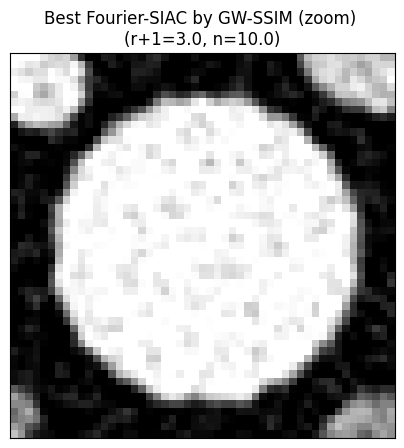

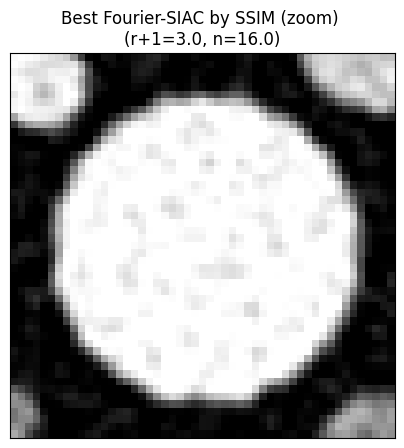

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Best Fourier-SIAC by SSIM (zoom) \n(r+1=3.0, n=16.0)'}>)

In [8]:
### plot the best of each metric (no duplicates) ###
df_siac2 = df_summary[df_summary["method"] == "Fourier-SIAC"].copy()

best_l2_row = df_siac2.loc[df_siac2["rel_l2_err"].idxmin()]
best_masked_l2_row = df_siac2.loc[df_siac2["masked_rel_l2_err"].idxmin()]
best_gw_ssim_row = df_siac2.loc[df_siac2["gw_ssim"].idxmax()]
best_ssim_row = df_siac2.loc[df_siac2["ssim"].idxmax()]

best_l2_name = best_l2_row["name"]
best_masked_l2_name = best_masked_l2_row["name"]
best_gwssim_name = best_gw_ssim_row["name"]
best_ssim_name = best_ssim_row["name"]

img_best_l2 = cases[best_l2_name]["image"]
img_best_masked_l2 = cases[best_masked_l2_name]["image"]
img_best_gwssim = cases[best_gwssim_name]["image"]
img_best_ssim = cases[best_ssim_name]["image"]

plot_img(img=fbp_hann, title="FBP (Hann)")
plot_img(
    img=img_best_l2,
    title=f"Best Fourier-SIAC by rel L2\n(r+1={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC by masked rel L2\n(r+1={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC by GW-SSIM\n(r+1={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC by SSIM\n(r+1={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

plot_img_zoom(img=fbp_hann, title="FBP (Hann) (zoom)")
plot_img_zoom(
    img=img_best_l2,
    title=f"Best Fourier-SIAC by rel L2 (zoom) \n(r+1={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC by masked rel L2 (zoom) \n(r+1={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC by GW-SSIM (zoom) \n(r+1={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC by SSIM (zoom) \n(r+1={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

### Plotting the Frequency Response

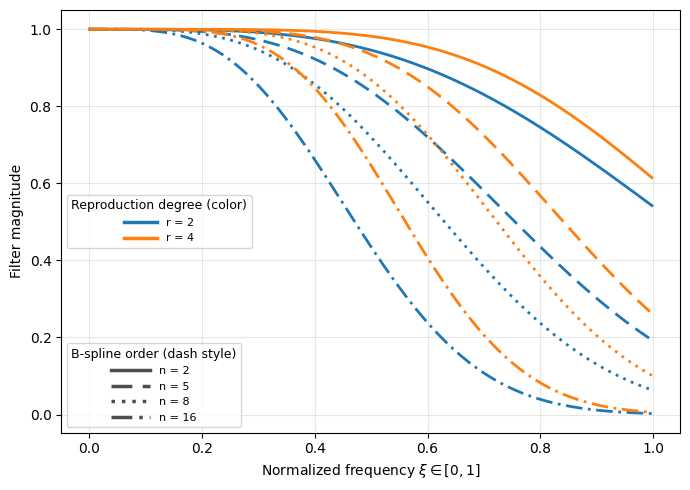

In [9]:
from matplotlib.lines import Line2D
from src.siac_fourier import siac_cgam_fourier, _siac_freq_response_1d

def plot_freq_response(
    N=1024,
    d=1.0,
    kernels=((2,2), (4,2), (2,5), (4,5), (2,8), (4,8)),
    save_name=None
):
    plt.figure(figsize=(7, 5))

    # Same convention as detector plot:
    # color = moments, dash style = BSorder
    color_map = {
        2: "C0",
        4: "C1",
        6: "C2",
    }

    dash_map = {
        2: None,             # solid
        5: (6, 3),           # dashed
        8: (1, 2),           # dotted
        16: (6, 2, 1, 2),    # dash-dot
    }

    omega = 2.0 * np.pi * np.fft.fftfreq(N, d=d)
    omega_max = np.max(np.abs(omega))

    # One-sided normalized frequency
    mask = omega >= 0
    xi = omega[mask] / omega_max

    for moments, BSorder in kernels:
        cgam = siac_cgam_fourier(moments, BSorder)
        S = _siac_freq_response_1d(N, d, moments, BSorder, cgam)

        (line,) = plt.plot(
            xi,
            np.real(S[mask]),   # or np.abs(S[mask]) if you want magnitude
            color=color_map.get(moments, "black"),
            linewidth=2.0
        )

        if dash_map.get(BSorder) is not None:
            line.set_dashes(dash_map[BSorder])

    plt.xlabel(r"Normalized frequency $\xi \in [0,1]$")
    plt.ylabel("Filter magnitude")
    if save_name is None:
        plt.title("SIAC frequency responses")

    plt.grid(True, alpha=0.3)

    ax = plt.gca()

    # Left legend: moments (color)
    handles_left = [
        Line2D([0], [0], color=color_map[2], lw=2.5, linestyle="-", label="r = 2"),
        Line2D([0], [0], color=color_map[4], lw=2.5, linestyle="-", label="r = 4"),
    ]
    leg1 = ax.legend(
        handles=handles_left,
        title="Reproduction degree (color)",
        loc="center left",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        handlelength=3.0
    )
    ax.add_artist(leg1)

    # Right legend: BSorder (dash style)
    handles_right = []
    BSorder_list = sorted(set(bs for _, bs in kernels))
    for bs in BSorder_list:
        h = Line2D([0], [0], color="0.3", lw=2.5, linestyle="-", label=f"n = {bs}")
        if dash_map.get(bs) is not None:
            h.set_dashes(dash_map[bs])
        handles_right.append(h)

    ax.legend(
        handles=handles_right,
        title="B-spline order (dash style)",
        loc="lower left",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        handlelength=3.5
    )

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(f"figures/{save_name}.pdf", dpi=300, bbox_inches="tight", pad_inches=0)

    plt.show()


_, d_det = data_space.cell_sides
plot_freq_response(
    N=1024,
    d=d_det,
    kernels=((2, 2), (4, 2), (2, 5), (4, 5), (2, 8), (4, 8), (2, 16), (4, 16)),
    save_name="siac_postprocessor_response"
)